In [3]:
# import modules
import os
import shutil
from glob import glob
import joblib
import importlib


import torch
import torch.nn as nn
import torchvision.models as models

from fogvision import gpuutils
from fogvision import fogimageclass
importlib.reload(fogimageclass)

<module 'fogvision.fogimageclass' from 'c:\\Users\\jnicolow\\Documents\\research\\fog\\FogVision\\fogvision\\fogimageclass.py'>

# data prep

In [2]:
data_dir = os.path.join('data', 'fine_tuning')
sitenames = os.listdir(data_dir)


NameError: name 'os' is not defined

In [3]:
results = {}  # store counts per site

for sitename in sitenames:
    site_dir = os.path.join(data_dir, sitename)

    # Build paths
    diurnal_clear = glob(os.path.join(site_dir, "diurnal", "clear", "*.jpg"))
    diurnal_fog   = glob(os.path.join(site_dir, "diurnal", "fog", "*.jpg"))
    noct_clear    = glob(os.path.join(site_dir, "nocturnal", "clear", "*.jpg"))
    noct_fog      = glob(os.path.join(site_dir, "nocturnal", "fog", "*.jpg"))

    # Count them
    counts = {
        "diurnal_clear": len(diurnal_clear),
        "diurnal_fog":   len(diurnal_fog),
        "nocturnal_clear": len(noct_clear),
        "nocturnal_fog":   len(noct_fog),
    }

    # Add totals
    counts["total_clear"] = counts["diurnal_clear"] + counts["nocturnal_clear"]
    counts["total_fog"]   = counts["diurnal_fog"]   + counts["nocturnal_fog"]
    counts["total"]       = counts["total_clear"]   + counts["total_fog"]

    results[sitename] = counts

# Print nicely
for sitename, c in results.items():
    print(f"\n=== {sitename} ===")
    print(f"Diurnal Clear:    {c['diurnal_clear']}")
    print(f"Diurnal Fog:      {c['diurnal_fog']}")
    print(f"Nocturnal Clear:  {c['nocturnal_clear']}")
    print(f"Nocturnal Fog:    {c['nocturnal_fog']}")
    print(f"Total Clear:      {c['total_clear']}")
    print(f"Total Fog:        {c['total_fog']}")
    print(f"TOTAL IMAGES:     {c['total']}")



=== finetune_output ===
Diurnal Clear:    0
Diurnal Fog:      0
Nocturnal Clear:  0
Nocturnal Fog:    0
Total Clear:      0
Total Fog:        0
TOTAL IMAGES:     0

=== Kaala ===
Diurnal Clear:    215
Diurnal Fog:      228
Nocturnal Clear:  56
Nocturnal Fog:    405
Total Clear:      271
Total Fog:        633
TOTAL IMAGES:     904

=== Kaala_diurnal_embeddings.pt ===
Diurnal Clear:    0
Diurnal Fog:      0
Nocturnal Clear:  0
Nocturnal Fog:    0
Total Clear:      0
Total Fog:        0
TOTAL IMAGES:     0

=== Kaala_nocturnal_embeddings.pt ===
Diurnal Clear:    0
Diurnal Fog:      0
Nocturnal Clear:  0
Nocturnal Fog:    0
Total Clear:      0
Total Fog:        0
TOTAL IMAGES:     0

=== Nakula ===
Diurnal Clear:    400
Diurnal Fog:      277
Nocturnal Clear:  513
Nocturnal Fog:    48
Total Clear:      913
Total Fog:        325
TOTAL IMAGES:     1238

=== Nakula_diurnal_embeddings.pt ===
Diurnal Clear:    0
Diurnal Fog:      0
Nocturnal Clear:  0
Nocturnal Fog:    0
Total Clear:      0
Tot

In [ ]:
# move files to dirunal/nocturnal dirs
import os
import shutil
from glob import glob
from fogvision import fogimageclass
import importlib
importlib.reload(fogimageclass)

data_dir = r'C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments'

# ── SAFETY SWITCH ──────────────────────────────────────────────────────────────
DRY_RUN = True   # Set to False only after you've verified the dry-run output
# ──────────────────────────────────────────────────────────────────────────────

# Matches: <annotator>/<sitename>/<fog|clear|likelyfog>/*.jpg
fns = glob(os.path.join(data_dir, '*', '*', '*', '*.jpg'))
fns += glob(os.path.join(data_dir, '*', '*', '*', '*.JPG'))

print(f"Found {len(fns)} images\n")

errors = []
moves = []

for fn in fns:
    try:
        image_class = fogimageclass.FogImage(fn)
        nocturnal = image_class.get_is_nocturnal()  # 1 = nocturnal, 0 = diurnal
        DoN = 'nocturnal' if nocturnal else 'diurnal'

        # Current:  .../annotator/sitename/label/image.jpg
        # Target:   .../annotator/sitename/diurnal|nocturnal/label/image.jpg
        label_dir = os.path.dirname(fn)          # .../annotator/sitename/label
        label     = os.path.basename(label_dir)  # fog | clear | likelyfog
        site_dir  = os.path.dirname(label_dir)   # .../annotator/sitename

        new_dir  = os.path.join(site_dir, DoN, label)
        new_path = os.path.join(new_dir, os.path.basename(fn))

        moves.append((fn, new_path, DoN))

        if DRY_RUN:
            print(f"[DRY RUN] {DoN:9s}  {fn}")
            print(f"        → {new_path}\n")
        else:
            os.makedirs(new_dir, exist_ok=True)
            shutil.move(fn, new_path)
            print(f"[MOVED]   {fn}\n       → {new_path}")

    except Exception as e:
        errors.append((fn, str(e)))
        print(f"[ERROR] {fn}\n  {e}\n")

# Summary
print("=" * 60)
print(f"Total images : {len(fns)}")
print(f"Planned moves: {len(moves)}")
diurnal_count  = sum(1 for _, _, d in moves if d == 'diurnal')
nocturnal_count = sum(1 for _, _, d in moves if d == 'nocturnal')
print(f"  diurnal    : {diurnal_count}")
print(f"  nocturnal  : {nocturnal_count}")
print(f"Errors       : {len(errors)}")
if errors:
    print("\nFailed files:")
    for fn, err in errors:
        print(f"  {fn}: {err}")

if DRY_RUN:
    print("\n⚠️  DRY RUN — no files were moved. Set DRY_RUN = False to execute.")

Found 4392 images

[MOVED]   C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\clear\01030385.JPG
       → C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\nocturnal\clear\01030385.JPG
[MOVED]   C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\clear\01030388.JPG
       → C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\nocturnal\clear\01030388.JPG
[MOVED]   C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\clear\01040578.JPG
       → C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\diurnal\clear\01040578.JPG
[MOVED]   C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\clear\01050616.JPG
       → C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments\Joel\Nakula\diurnal\clear\01050616.JPG
[MOVED]   C:\Users\jnicolow\D

# FogVision image classification models
There are two fogvision inference classification heads one for diurnal and one for nocturnal imagery; both working with resnet50 embeddings

In [4]:
# initialize embedder 
basemodel = models.resnet50(pretrained=True)

num_ftrs = basemodel.fc.in_features
basemodel.fc = nn.Identity()  # Set the classification layer to identity to output embeddings

# choose device
device = gpuutils.get_gpu_most_memory() # if gpus avaible get one with most memory
print(device)

# put the model in evaluation mode
model = basemodel.to(device)
model.eval()


# initialize classification heads (saved from cpu)
if 'cpu' in str(device):
    diurnal_classif_head = torch.load(os.path.join('models', f'fogvision_inference_head_model_diurnal_cpu.pkl'), map_location=device) # NOTE when running model on cpu
    nocturnal_classif_head = torch.load(os.path.join('models', f'fogvision_inference_head_model_nocturnal_cpu.pkl'), map_location=device) # when loading onto cuda
else:
    diurnal_classif_head = joblib.load(os.path.join('models', f'fogvision_inference_head_model_diurnal.pkl')) # NOTE when loading onto cuda
    nocturnal_classif_head = joblib.load(os.path.join('models', f'fogvision_inference_head_model_nocturnal.pkl')) 



c:\Users\jnicolow\AppData\Local\miniconda3\envs\fogvision\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jnicolow\AppData\Local\miniconda3\envs\fogvision\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cuda:1


In [ ]:
from torch.utils.data import DataLoader
from fogvision import finetuning
import importlib
importlib.reload(finetuning)
importlib.reload(fogimageclass)
# fine tuning
sitenames = ['honouliuli']
for sitename in sitenames:
    for DoN in ['diurnal', 'nocturnal']:
        fns = glob(os.path.join(data_dir, sitename, DoN, '*', '*.jpg'))
        full_dataset = finetuning.SiteEmbeddingDataset(
            image_fns=fns,
            basemodel=basemodel,
            disable_tqdm=False
        )
        embedding_save_path = os.path.join(data_dir, f'{sitename}_{DoN}_embeddings.pt')
        torch.save({'embeddings': full_dataset.embeddings, 
                    'labels': full_dataset.labels,
                    'fns': full_dataset.image_fns}, embedding_save_path)

In [6]:
# based on new annotations
from torch.utils.data import DataLoader
from fogvision import finetuning
import importlib
importlib.reload(finetuning)
importlib.reload(fogimageclass)
# fine tuning
data_dir = r'C:\Users\jnicolow\Documents\research\fog\March_2026_annotator_assignments'
sitenames = ['honouliuli', 'honouliuli2', 'Kaala', 'Nakula', 'ParkHQ']

for sitename in sitenames:
    for DoN in ['diurnal', 'nocturnal']:
        fns = glob(os.path.join(data_dir, '*', sitename, DoN, '*', '*.jpg'))
        full_dataset = finetuning.SiteEmbeddingDataset(
            image_fns=fns,
            basemodel=basemodel,
            disable_tqdm=False
        )
        if sitename == 'honouliuli2': sitename = 'honouliuli'
        embedding_save_path = os.path.join(data_dir, f'{sitename}_{DoN}_embeddings.pt')
        if os.path.exists(embedding_save_path):
            # add to the exsisting .pt file
            existing_data = torch.load(embedding_save_path)
            combined_embeddings = torch.cat((existing_data['embeddings'], full_dataset.embeddings), dim=0)
            combined_labels = torch.cat((existing_data['labels'], full_dataset.labels), dim=0)
            combined_fns = existing_data['fns'] + full_dataset.image_fns
            torch.save({'embeddings': combined_embeddings, 
                        'labels': combined_labels,
                        'fns': combined_fns}, embedding_save_path)
        else:
            torch.save({'embeddings': full_dataset.embeddings, 
                        'labels': full_dataset.labels,
                        'fns': full_dataset.image_fns}, embedding_save_path)

  0%|          | 0/128 [00:00<?, ?it/s]

100%|██████████| 128/128 [00:10<00:00, 11.91it/s]


Loaded 128 images | Fog: 32 | Clear: 96


0it [00:00, ?it/s]


Loaded 0 images | Fog: 0 | Clear: 0


...

Loaded 335 images | Fog: 25 | Clear: 310


100%|██████████| 239/239 [00:43<00:00,  5.50it/s]


Loaded 239 images | Fog: 21 | Clear: 218


100%|██████████| 293/293 [00:54<00:00,  5.39it/s]

Loaded 293 images | Fog: 8 | Clear: 285


# tune decision threshold

In [7]:
import numpy as np
import copy
import pandas as pd
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [17]:
from sklearn.metrics import roc_curve as sk_roc_curve

importlib.reload(finetuning)
results = []
roc_data = {}  # store roc curves for the first plot column
N_SHUFFLES = 6
data_dir = os.path.join('data', 'fine_tuning')
for sitename in sitenames:
    if '2' in sitename: continue # skip honouliuli2 since its data is already included in honouliuli
    for DoN in ['diurnal', 'nocturnal']:
        embedding_save_path = os.path.join(data_dir, f'{sitename}_{DoN}_embeddings.pt')
        dataset = finetuning.PrecomputedEmbeddingDataset(embedding_save_path)
        if not len(dataset): continue
        
        classif_head = diurnal_classif_head if DoN == 'diurnal' else nocturnal_classif_head
        
        test_indices, train_pool_indices = finetuning.get_balanced_test_indices(dataset, n_per_class=50)
        test_loader = DataLoader(Subset(dataset, test_indices), batch_size=16, shuffle=False)
        
        # 0-shot default threshold + collect ROC curve data
        model = copy.deepcopy(classif_head).to(device)
        metrics, probs, labels = finetuning.evaluate_with_probs(model, test_loader, device, threshold=0.5)
        fpr, tpr, _ = sk_roc_curve(labels, probs)
        roc_data[(sitename, DoN)] = (fpr, tpr, metrics['auroc'])

        results.append({'site': sitename, 'DoN': DoN, 'n_calib': 0, 'shuffle': -1, **metrics})
        print(f"{sitename} {DoN} | n_calib=0 | {metrics}")

        fog_idx = [i for i in train_pool_indices if dataset[i][1] == 1]
        clear_idx = [i for i in train_pool_indices if dataset[i][1] == 0]
        max_balanced_n = min(len(fog_idx), len(clear_idx)) * 2

        for shuffle_idx in range(N_SHUFFLES):
            shuffled_fog = fog_idx.copy()
            shuffled_clear = clear_idx.copy()
            np.random.shuffle(shuffled_fog)
            np.random.shuffle(shuffled_clear)
            shuffled_pool = shuffled_fog + shuffled_clear

            threshold_example = -np.inf
            for n_calib in range(20, min(max_balanced_n, 200) + 1, 20):
                calib_indices = finetuning.get_balanced_train_indices(shuffled_pool, dataset, n_calib)
                calib_loader = DataLoader(Subset(dataset, calib_indices), batch_size=16, shuffle=False)

                model = copy.deepcopy(classif_head).to(device)
                threshold = finetuning.find_optimal_threshold(model, calib_loader, device, objective='balanced')
                if n_calib == 60:
                    threshold_example = threshold
                metrics, _, _ = finetuning.evaluate_with_probs(model, test_loader, device, threshold=threshold)

                results.append({'site': sitename, 'DoN': DoN, 'n_calib': n_calib,
                                'shuffle': shuffle_idx, **metrics})
                print(f"{sitename} {DoN} | shuffle={shuffle_idx} | n_calib={n_calib} | thresh={threshold:.2f} | {metrics}")
        if threshold_example == -np.inf:
            threshold_example = threshold
        # # --- Save per-image test results ---
        # out_dir = os.path.join(data_dir, 'finetune_output', sitename, DoN)
        # finetuning.save_test_image_plots(
        #     dataset, test_indices, model, device,
        #     output_dir=out_dir,
        #     sitename=sitename, DoN=DoN,
        #     default_thresh=0.5,
        #     optimal_thresh=threshold_example
        # )

results_df = pd.DataFrame(results)

c:\Users\jnicolow\Documents\research\fog\FogVision\fogvision\finetuning.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath)


honouliuli diurnal | n_calib=0 | {'auroc': np.float64(0.996), 'accuracy': 0.92, 'precision': 1.0, 'f1': 0.9130434782608695}
honouliuli diurnal | shuffle=0 | n_calib=20 | thresh=0.10 | {'auroc': np.float64(0.996), 'accuracy': 0.95, 'precision': 1.0, 'f1': 0.9473684210526315}
honouliuli diurnal | shuffle=0 | n_calib=40 | thresh=0.80 | {'auroc': np.float64(0.996), 'accuracy': 0.9, 'precision': 1.0, 'f1': 0.8888888888888888}
honouliuli diurnal | shuffle=1 | n_calib=20 | thresh=0.99 | {'auroc': np.float64(0.996), 'accuracy': 0.79, 'precision': 1.0, 'f1': 0.7341772151898734}
honouliuli diurnal | shuffle=1 | n_calib=40 | thresh=0.80 | {'auroc': np.float64(0.996), 'accuracy': 0.9, 'precision': 1.0, 'f1': 0.8888888888888888}
honouliuli diurnal | shuffle=2 | n_calib=20 | thresh=0.81 | {'auroc': np.float64(0.996), 'accuracy': 0.9, 'precision': 1.0, 'f1': 0.8888888888888888}
honouliuli diurnal | shuffle=2 | n_calib=40 | thresh=0.10 | {'auroc': np.float64(0.996), 'accuracy': 0.95, 'precision': 1.0,

c:\Users\jnicolow\Documents\research\fog\FogVision\fogvision\finetuning.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath)


Kaala diurnal | shuffle=0 | n_calib=120 | thresh=0.18 | {'auroc': np.float64(0.9068), 'accuracy': 0.84, 'precision': 0.8541666666666666, 'f1': 0.8367346938775511}
Kaala diurnal | shuffle=0 | n_calib=140 | thresh=0.12 | {'auroc': np.float64(0.9068), 'accuracy': 0.86, 'precision': 0.86, 'f1': 0.86}
Kaala diurnal | shuffle=0 | n_calib=160 | thresh=0.12 | {'auroc': np.float64(0.9068), 'accuracy': 0.86, 'precision': 0.86, 'f1': 0.86}
Kaala diurnal | shuffle=0 | n_calib=180 | thresh=0.14 | {'auroc': np.float64(0.9068), 'accuracy': 0.86, 'precision': 0.86, 'f1': 0.86}
Kaala diurnal | shuffle=0 | n_calib=200 | thresh=0.18 | {'auroc': np.float64(0.9068), 'accuracy': 0.84, 'precision': 0.8541666666666666, 'f1': 0.8367346938775511}
Kaala diurnal | shuffle=1 | n_calib=20 | thresh=1.00 | {'auroc': np.float64(0.9068), 'accuracy': 0.55, 'precision': 1.0, 'f1': 0.18181818181818182}
Kaala diurnal | shuffle=1 | n_calib=40 | thresh=0.98 | {'auroc': np.float64(0.9068), 'accuracy': 0.6, 'precision': 1.0, '

c:\Users\jnicolow\Documents\research\fog\FogVision\fogvision\finetuning.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath)
c:\Users\jnicolow\Do

Nakula diurnal | n_calib=0 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.61, 'precision': 1.0, 'f1': 0.36065573770491804}
Nakula diurnal | shuffle=0 | n_calib=20 | thresh=0.03 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.89, 'precision': 0.8979591836734694, 'f1': 0.8888888888888888}
Nakula diurnal | shuffle=0 | n_calib=40 | thresh=0.03 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.89, 'precision': 0.8979591836734694, 'f1': 0.8888888888888888}
Nakula diurnal | shuffle=0 | n_calib=60 | thresh=0.03 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.89, 'precision': 0.8979591836734694, 'f1': 0.8888888888888888}
Nakula diurnal | shuffle=0 | n_calib=80 | thresh=0.03 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.89, 'precision': 0.8979591836734694, 'f1': 0.8888888888888888}
Nakula diurnal | shuffle=0 | n_calib=100 | thresh=0.03 | {'auroc': np.float64(0.9443999999999999), 'accuracy': 0.89, 'precision': 0.8979591836734694, 'f1': 0.88888888

c:\Users\jnicolow\Documents\research\fog\FogVision\fogvision\finetuning.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath)
c:\Users\jnicolow\Do

ParkHQ diurnal | shuffle=1 | n_calib=60 | thresh=0.03 | {'auroc': np.float64(0.952), 'accuracy': 0.83, 'precision': 0.9024390243902439, 'f1': 0.8131868131868132}
ParkHQ diurnal | shuffle=1 | n_calib=80 | thresh=0.03 | {'auroc': np.float64(0.952), 'accuracy': 0.83, 'precision': 0.9024390243902439, 'f1': 0.8131868131868132}
ParkHQ diurnal | shuffle=1 | n_calib=100 | thresh=0.00 | {'auroc': np.float64(0.952), 'accuracy': 0.86, 'precision': 0.8333333333333334, 'f1': 0.8653846153846154}
ParkHQ diurnal | shuffle=2 | n_calib=20 | thresh=0.01 | {'auroc': np.float64(0.952), 'accuracy': 0.86, 'precision': 0.8333333333333334, 'f1': 0.8653846153846154}
ParkHQ diurnal | shuffle=2 | n_calib=40 | thresh=0.01 | {'auroc': np.float64(0.952), 'accuracy': 0.86, 'precision': 0.8333333333333334, 'f1': 0.8653846153846154}
ParkHQ diurnal | shuffle=2 | n_calib=60 | thresh=0.03 | {'auroc': np.float64(0.952), 'accuracy': 0.83, 'precision': 0.9024390243902439, 'f1': 0.8131868131868132}
ParkHQ diurnal | shuffle=2 

c:\Users\jnicolow\Documents\research\fog\FogVision\fogvision\finetuning.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath)


ParkHQ nocturnal | shuffle=0 | n_calib=140 | thresh=0.25 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.8, 'precision': 0.9411764705882353, 'f1': 0.7619047619047619}
ParkHQ nocturnal | shuffle=1 | n_calib=20 | thresh=0.37 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.72, 'precision': 0.9583333333333334, 'f1': 0.6216216216216216}
ParkHQ nocturnal | shuffle=1 | n_calib=40 | thresh=0.29 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.77, 'precision': 0.9354838709677419, 'f1': 0.7160493827160493}
ParkHQ nocturnal | shuffle=1 | n_calib=60 | thresh=0.29 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.77, 'precision': 0.9354838709677419, 'f1': 0.7160493827160493}
ParkHQ nocturnal | shuffle=1 | n_calib=80 | thresh=0.25 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.8, 'precision': 0.9411764705882353, 'f1': 0.7619047619047619}
ParkHQ nocturnal | shuffle=1 | n_calib=100 | thresh=0.25 | {'auroc': np.float64(0.7412000000000001), 'accuracy': 0.8

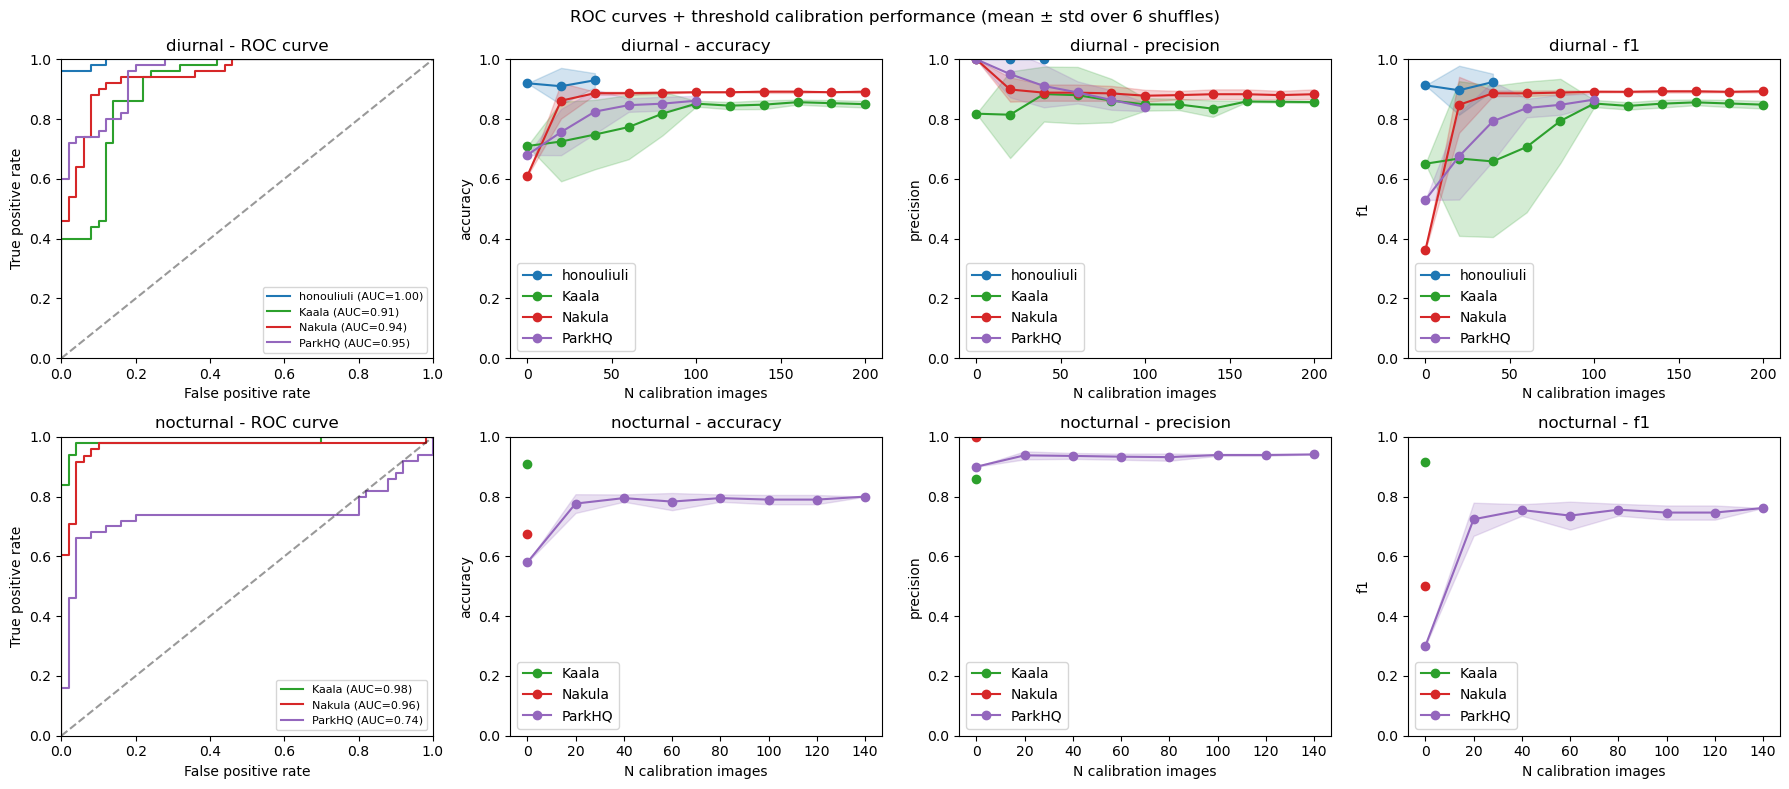

In [18]:
metrics_to_plot = ['accuracy', 'precision', 'f1']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

colors = {sitename: f'C{i}' for i, sitename in enumerate(sitenames)}

for row, DoN in enumerate(['diurnal', 'nocturnal']):
    
    # --- Column 0: ROC curves ---
    ax = axes[row, 0]
    for sitename in sitenames:
        key = (sitename, DoN)
        if key not in roc_data:
            continue
        fpr, tpr, auroc = roc_data[key]
        ax.plot(fpr, tpr, label=f'{sitename} (AUC={auroc:.2f})', color=colors[sitename])
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'{DoN} - ROC curve')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(False)

    # --- Columns 1-3: calibration metrics ---
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col + 1]
        
        for sitename in sitenames:
            subset = results_df[(results_df['site'] == sitename) & (results_df['DoN'] == DoN)]
            if subset.empty:
                continue

            zero_shot = subset[subset['shuffle'] == -1][['n_calib', metric]]
            grouped = subset[subset['shuffle'] >= 0].groupby('n_calib')[metric]
            mean = grouped.mean()
            std = grouped.std()

            all_x = np.concatenate([[0], mean.index])
            all_mean = np.concatenate([zero_shot[metric].values, mean.values])
            all_std = np.concatenate([[0], std.values])

            line, = ax.plot(all_x, all_mean, marker='o', label=sitename, color=colors[sitename])
            ax.fill_between(all_x, all_mean - all_std, all_mean + all_std,
                            alpha=0.2, color=line.get_color())

        ax.set_title(f'{DoN} - {metric}')
        ax.set_xlabel('N calibration images')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(False)

plt.suptitle('ROC curves + threshold calibration performance (mean ± std over 6 shuffles)')
plt.tight_layout()
plt.show()

# fine tune model

In [ ]:
import numpy as np
import copy
import pandas as pd
from torch.utils.data import DataLoader, Subset

importlib.reload(finetuning)
results = []
N_SHUFFLES = 3
TRAIN_INTERVALS = 20
for sitename in sitenames:
    for DoN in ['diurnal', 'nocturnal']:
        embedding_save_path = os.path.join(data_dir, f'{sitename}_{DoN}_embeddings.pt')
        dataset = finetuning.PrecomputedEmbeddingDataset(embedding_save_path)
        
        classif_head = diurnal_classif_head if DoN == 'diurnal' else nocturnal_classif_head
        
        test_indices, train_pool_indices = finetuning.get_balanced_test_indices(dataset, n_per_class=50)
        test_loader = DataLoader(Subset(dataset, test_indices), batch_size=16, shuffle=False)
        
        # 0-shot: only need once, not per shuffle
        metrics = finetuning.evaluate(copy.deepcopy(classif_head).to(device), test_loader, device)
        results.append({'site': sitename, 'DoN': DoN, 'n_train': 0, 'shuffle': -1, **metrics})
        print(f"{sitename} {DoN} | n_train=0 | {metrics}")
        
        fog_idx = [i for i in train_pool_indices if dataset[i][1] == 1]
        clear_idx = [i for i in train_pool_indices if dataset[i][1] == 0]
        max_balanced_n = min(len(fog_idx), len(clear_idx)) * 2

        for shuffle_idx in range(N_SHUFFLES):
            # Shuffle fog and clear independently so balance is preserved
            shuffled_fog = fog_idx.copy()
            shuffled_clear = clear_idx.copy()
            np.random.shuffle(shuffled_fog)
            np.random.shuffle(shuffled_clear)
            shuffled_pool = shuffled_fog + shuffled_clear

            for n_train in range(TRAIN_INTERVALS, max_balanced_n + 1, 20):
                train_indices = finetuning.get_balanced_train_indices(shuffled_pool, dataset, n_train)
                train_loader = DataLoader(Subset(dataset, train_indices), 
                                         batch_size=min(16, n_train), shuffle=True)
                
                metrics = finetuning.finetune_and_evaluate(classif_head, train_loader, test_loader, 
                                                           device, epochs=20, lr=1e-3, layers_to_unfreeze='last_only')
                results.append({'site': sitename, 'DoN': DoN, 'n_train': n_train, 
                                'shuffle': shuffle_idx, **metrics})
                print(f"{sitename} {DoN} | shuffle={shuffle_idx} | n_train={n_train} | {metrics}")

results_df = pd.DataFrame(results)

In [ ]:
metrics_to_plot = ['auroc', 'accuracy', 'precision', 'f1']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, DoN in enumerate(['diurnal', 'nocturnal']):
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        
        for sitename in sitenames:
            subset = results_df[(results_df['site'] == sitename) & (results_df['DoN'] == DoN)]
            
            if subset.empty:
                continue

            # 0-shot point (shuffle=-1, only one value)
            zero_shot = subset[subset['shuffle'] == -1][['n_train', metric]]
            
            # Average across shuffles for n_train > 0
            grouped = subset[subset['shuffle'] >= 0].groupby('n_train')[metric]
            mean = grouped.mean()
            std = grouped.std()
            
            # Combine 0-shot with the rest
            all_x = np.concatenate([[0], mean.index])
            all_mean = np.concatenate([zero_shot[metric].values, mean.values])
            all_std = np.concatenate([[0], std.values])
            
            line, = ax.plot(all_x, all_mean, marker='o', label=sitename)
            color = line.get_color()
            ax.fill_between(all_x, all_mean - all_std, all_mean + all_std, alpha=0.2, color=color)
        
        ax.set_title(f'{DoN} - {metric}')
        ax.set_xlabel('N training images')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(False)

plt.suptitle('Fine-tuning performance vs training set size (mean ± std over 3 shuffles)')
plt.tight_layout()
plt.show()

# FogVision image classification
The fog image class can be used to classify images (as shown below). Given the image filepath, the embedding mode and the classification head model. If the image [center] is gray scale the nocturnal model will be used.

In [ ]:
import importlib
importlib.reload(fogimageclass)
image_fns = glob(os.path.join('data', 'images', '*.jpg'))

crop_size = None # if crop size is None then it will take largest crop possible

for fn in image_fns:
    fog_img_class = fogimageclass.FogImage(filepath=fn, crop_size=crop_size)
    if fog_img_class.nocturnal:
        fog_img_class.get_fog_val(model=nocturnal_classif_head, embedding_model=basemodel, random_crop=False) # NOTE only takes image embedding from 
        # fog_img_class.get_fog_val_multiple_regions(model=nocturnal_classif_head, embedding_model=basemodel) # NOTE not ideal for images with a lot of open sky works best on forested environments
    else:
        fog_img_class.get_fog_val(model=diurnal_classif_head, embedding_model=basemodel, random_crop=False)
        # fog_img_class.get_fog_val_multiple_regions(model=diurnal_classif_head, embedding_model=basemodel)

    fog_img_class.plot_image(plot_crop=False) # plot image with nocturnal and fog value
